# **Caso: Factores que Impactan el Desempeño en Matemáticas**

Una universidad ha recopilado información sobre el desempeño de sus estudiantes en matemáticas con el objetivo de identificar los factores que más influyen en su rendimiento. Se busca entender cómo aspectos como el tiempo de estudio, la asistencia a actividades extracurriculares y las horas de sueño inciden en el puntaje final.

## **Importación de librerías necesarias**

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from IPython.display import display
import plotly.graph_objects as go
from google.colab import data_table
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

## **Funciones utilizadas**

In [22]:
DARK_BLUE_PALETTE = ["#1E3A8A", "#1E4FA1", "#1E63B8", "#1E78CF", "#1E8CE6"]

def univariate_analysis(df, variable):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Boxplot
    sns.boxplot(data=df, x=variable, ax=axes[0,0], color=DARK_BLUE_PALETTE[2])
    # Histograma
    sns.histplot(data=df, x=variable, kde=True, ax=axes[0,1],
                 color=DARK_BLUE_PALETTE[1], edgecolor=DARK_BLUE_PALETTE[4])
    # Violin plot
    sns.violinplot(data=df, x=variable, ax=axes[1,0],
                   color=DARK_BLUE_PALETTE[1], inner_kws=dict(box_width=10))
    # Strip plot
    sns.stripplot(data=df, x=variable, ax=axes[1,1], alpha=0.4,
                  color=DARK_BLUE_PALETTE[3], jitter=True)

    axes[0,0].set_title('Boxplot')
    axes[0,1].set_title('Histograma')
    axes[1,0].set_title('Violin plot')
    axes[1,1].set_title('Strip plot')

    plt.tight_layout()
    plt.show()

In [23]:
def univariate_integer_analysis(df):
    exclude = ['Previous Scores']
    int_cols = [col for col in df.select_dtypes(include='int').columns if col not in exclude]

    for col in int_cols:
        print(f'Variable: {col}')
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Gráfico de barras
        sns.countplot(data=df, x=col, ax=axes[0], palette=DARK_BLUE_PALETTE[1:4])
        # Boxplot
        sns.boxplot(data=df, x=col, ax=axes[1], color=DARK_BLUE_PALETTE[2])

        axes[0].set_title('Gráfico de barras')
        axes[1].set_title('Boxplot')

        plt.tight_layout()
        plt.show()

## **Importación de Datos**

In [10]:
# Urls
url_math = 'https://raw.githubusercontent.com/daramireh/simonBolivarCienciaDatos/refs/heads/main/Student_Performance.csv'

# Carga de dataset
df_ma = pd.read_csv(url_math)

## **Análisis Exploratorio de Datos**

In [11]:
display(df_ma.head(100))

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
95,3,48,No,7,5,30.0
96,8,64,No,5,1,57.0
97,6,95,Yes,6,7,81.0
98,3,55,Yes,5,4,36.0


La tabla presenta un conjunto de datos con información sobre hábitos académicos y desempeño. Se observan variables numéricas como horas de estudio (entre 1-8 horas), puntajes previos (desde 48 hasta 99), horas de sueño (4-9 horas), cantidad de exámenes de práctica realizados (1-7) y un índice de rendimiento que varía considerablemente (25-91). También incluye una variable categórica sobre participación en actividades extracurriculares (Sí/No). Los datos muestran una amplia variabilidad en los patrones de estudio y rendimiento, donde algunos estudiantes con pocas horas de estudio pero altas notas previas (como el caso de 7 horas estudiadas y 99 de puntaje previo) logran buenos resultados (91 de índice), mientras que otros con más horas de estudio pero bajos puntajes previos (8 horas y 51 de puntaje) presentan rendimientos menores (45 de índice). Esta diversidad sugiere que el desempeño académico depende de múltiples factores combinados.

In [12]:
# Información del conjunto de datos
df_ma.info()

# Tipos de variables
tipos_variables = pd.DataFrame(df_ma.dtypes, columns=['Tipo de Dato'])


# Valores nulos
valores_nulos = pd.DataFrame(df_ma.isnull().sum(), columns=['Valores Nulos'])

# Filas duplicadas
duplicados = df_ma.duplicated().sum()

estructura_datos = pd.concat([tipos_variables, valores_nulos], axis=1)
estructura_datos['Valores Duplicados'] = duplicados

display(estructura_datos)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


,Tipo de Dato,Valores Nulos,Valores Duplicados
Hours Studied,int64,0,127
Previous Scores,int64,0,127
Extracurricular Activities,object,0,127
Sleep Hours,int64,0,127
Sample Question Papers Practiced,int64,0,127
Performance Index,float64,0,127


Primeramente notemos que el dataset no contiene ningun dato nulo, que nuestro dataset original consta de **1 variable categorica** y **5 numericas**, lo que nos reta a extraer informacion valiosa de los datos que tenemos. En este mismo analisis se reportan **127 filas** con alguna repeticion durante el dataset, esto implicaria ser objeto de revision para tomar decisiones en cuanto a ello.

Ahora pongamos la lupa sobre esos datos faltantes y que podemos aprender de ellos.

In [13]:
display(df_ma[df_ma.duplicated()])

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
915,9,52,No,5,9,48.0
1477,7,61,Yes,6,8,54.0
1601,5,99,No,7,5,89.0
1786,2,62,Yes,9,4,40.0
2026,5,87,Yes,6,7,74.0
...,...,...,...,...,...,...
9644,4,91,Yes,4,3,71.0
9940,8,95,No,5,2,90.0
9954,6,97,No,8,7,92.0
9966,1,41,No,7,3,12.0


Por la forma en la cual esta contenida la informacion no tenemos la certeza de que se presenten datos repetidos, ya que es posible que al ser tantos ocurran casos en donde los valores de las variables sean los mismos para **2 personas** como tal sin que esto se convierta en un duplicado, ya que carecemos de un **id unico** que nos permita afirmar la duplicacion, por lo cual se trabajara de manera normal con los datos.

Habiendo dicho esto procedamos con la transformacion de los datos para recolectar informacion valiosa de los mismos.

## **Transformacion de datos**

La guía hace una pregunta de si es necesario transformar los datos para tener un mejor conocimiento de los mismos, en lo que ha respuesta a la pregunta.

Sí, es necesario transformar algunos datos para mejorar el entendimiento y facilitar el análisis, esto asociado algunos factores entre ellos, la codificación de la variable categorica para su posterio análisis en modelos estadísticos, también se necesita escalar los datos, ya que para variables como `Performance Index`, `Hours Studied`, `Previous Scores`, `Sleep Hours` y `Sample Question Papers Practiced`, y además de esto trabajar con variables que surgen de las otras como indicadores que nos sirven para obtener nuevas variables que aporten al modelo de una manera eficiente.


### **Incorporación de indicadores en el estudio**

La incorporación de los indicadores Índice de Sostenibilidad Integral *(ISI)*, Índice de Balance Integral *(IBI)* e Índice de Eficiencia de Dedicación *(IED)* al estudio tiene como objetivo sacar el máximo potencial de los datos que tenemos generando así una mayor asertividad en el análisis. Estos índices fueron buscados en la literatura asociándonos en los datos disponibles.

1. **Índice de Sostenibilidad Integral (ISI)**

  Se trata de un indicador que ayuda a evaluar la sostenibilidad del desempeño académico, puesto que no solo considera la carga académica directa sino que también incluye actividades que, aunque no contribuyen a conocimientos concretos, son necesarios para la formación integral de los estudiantes. Por otro lado, las horas de sueño también están incluidas en la lista, dado que no solo es un factor de bienestar general sino también un determinante clave de las capacidades cognitivas. Asimismo, la inclusión de estos factores al estudio ayudará a identificar aquellos casos en los que los estudiantes se vean sometidos a una carga excesiva que pueda comprometer su sostenibilidad en el tiempo.

  $\texttt{ISI} = \texttt{Rendimiento Académico} / ((\texttt{Horas de estudio} + \texttt{Horas de actividades }) / \texttt{Horas de sueño})$


2. **Índice de Balance Integral (IBI)**

  Incluir el Índice de Balance Integral facilita entender cómo los estudiantes gestionan sus tiempos entre estudio, descanso y actividades extracurriculares.
  Este indicador nos permite ver que tan balanceadas estan las actividades del estuciante lo que puede afectar directamente al rendimiento academico.

  $\texttt{IBI} = (\texttt{Horas de estudio} / \texttt{Horas de sueño}) × (\texttt{Horas de actividades extracurriculares} / \texttt{Horas de descanso recomendadas})$

3. **Índice de Eficiencia de Dedicación (IED)**

  El Índice de Eficiencia de Dedicación proporciona una medida objetiva de cómo se traducen las horas invertidas en estudio y descanso en resultados académicos. Este indicador es util para encontrar patrones en los datos los cuales permiten asociar el tiempo que los estudiantes le dedican diario al estudio.

  $IED = \texttt{Rendimiento Académico} × (\texttt{Horas de estudio} + \texttt{Ejemplos practicados} + \texttt{Horas de sueño}) / 24$

#### **Cálculo de Índices**

In [14]:
df_ma['Extracurricular Hours'] = df_ma['Extracurricular Activities'].map({'Yes': 2, 'No': 0})

df_ma['ISI'] = df_ma['Performance Index'] / ((df_ma['Hours Studied'] + df_ma['Extracurricular Hours']) / df_ma['Sleep Hours'])

df_ma['IBI'] = (df_ma['Hours Studied'] / df_ma['Sleep Hours']) * (df_ma['Extracurricular Hours'] / 8)

df_ma['IED'] = df_ma['Performance Index'] * (df_ma['Hours Studied'] + df_ma['Sample Question Papers Practiced'] + df_ma['Sleep Hours']) / 24


### **Diccionario de Variables**

| Variable                            | Descripción                                                                                       | Tipo de dato |
|-------------------------------------|----------------------------------------------------------------------------------------------------|--------------|
| `Hours Studied`                     | Número de horas dedicadas al estudio por día o semana.                                             | Numérica     |
| `Previous Scores`                   | Puntaje previo o histórico del estudiante.                                                        | Numérica     |
| `Extracurricular Activities`        | Participación en actividades extracurriculares (`Yes` o `No`).                                    | Categórica   |
| `Extracurricular Hours`             | Horas asignadas a actividades extracurriculares (0 si `No`, 2 si `Yes`).                          | Numérica     |
| `Sleep Hours`                       | Horas promedio de sueño del estudiante.                                                            | Numérica     |
| `Sample Question Papers Practiced` | Número de ejemplos o ejercicios adicionales que el estudiante ha practicado.                      | Numérica     |
| `Performance Index`                | Índice de desempeño académico del estudiante.                                                      | Numérica     |
| `ISI` (Índice de Sostenibilidad Integral) | Relación entre rendimiento académico y carga + descanso. Evalúa sostenibilidad académica.     | Numérica     |
| `IBI` (Índice de Balance Integral)        | Mide qué tan balanceado está el tiempo entre estudio, sueño y actividades extracurriculares.     | Numérica     |
| `IED` (Índice de Eficiencia de Dedicación) | Evalúa la eficiencia de las horas dedicadas (estudio, sueño, práctica) en relación al rendimiento. | Numérica     |


### **Estadística descriptiva de variables**

#### **Análisis Univariado**

##### **Previous Scores**

Las notas anteriores tuvieron desempeños muy variados, sin tendencias dominantes hacia lo alto o lo bajo. esto puede sugerir de que no hubo factores que sistematicamente afectaran el rendimiento de los estudiantes por ejemplo como que el examen estuviera dificil.

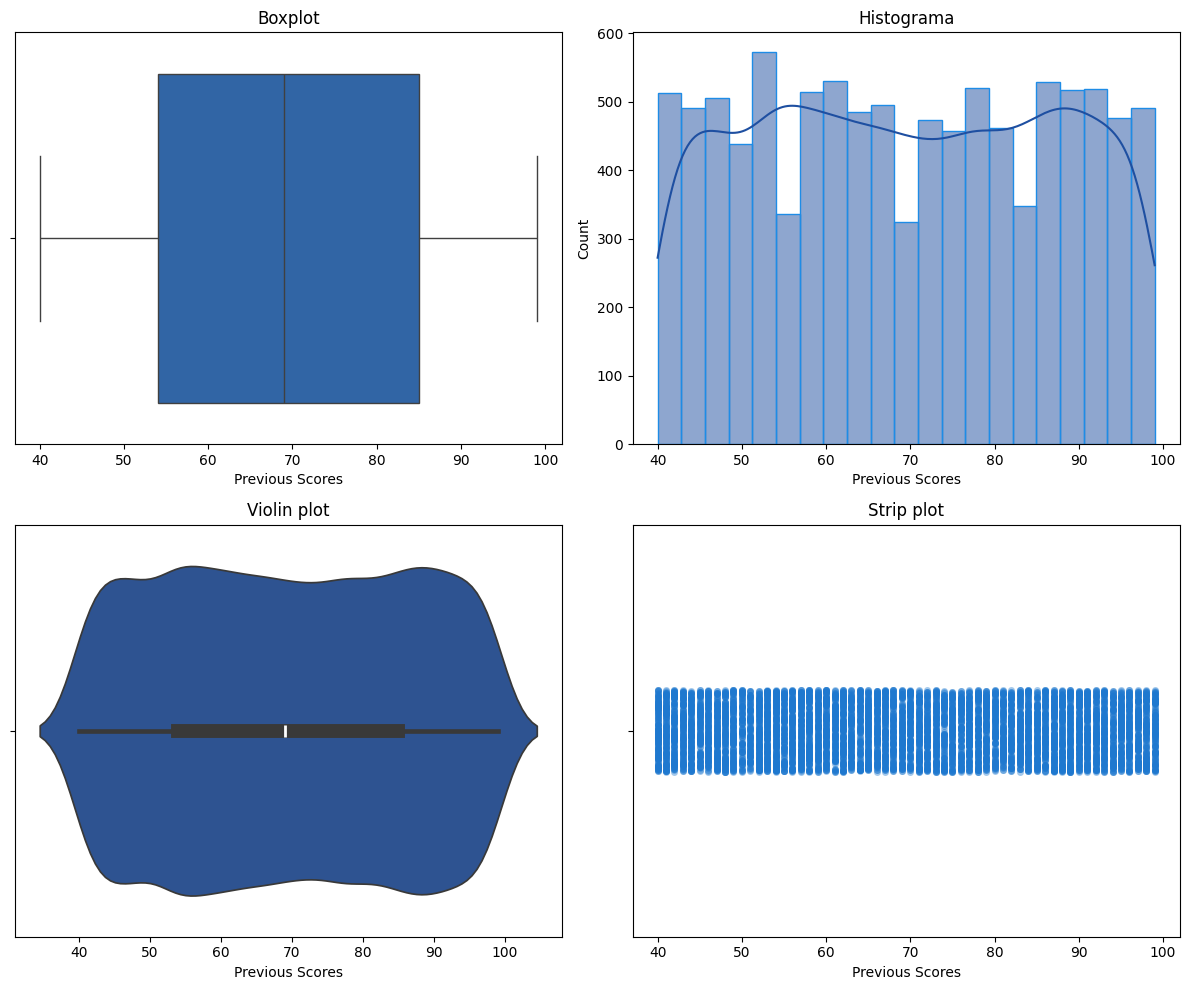

In [24]:
univariate_analysis(df_ma, 'Previous Scores')

##### **Performance Index**

Esta variable refleja un patrón clásico de distribución normal (en forma de campana), donde la mayoría de los estudiantes tienen un rendimiento cercano al promedio, y pocos se ubican en los extremos (muy alto o muy bajo). Lo cual evidencia un comportamiento normal en lo que seria un grupo academico.

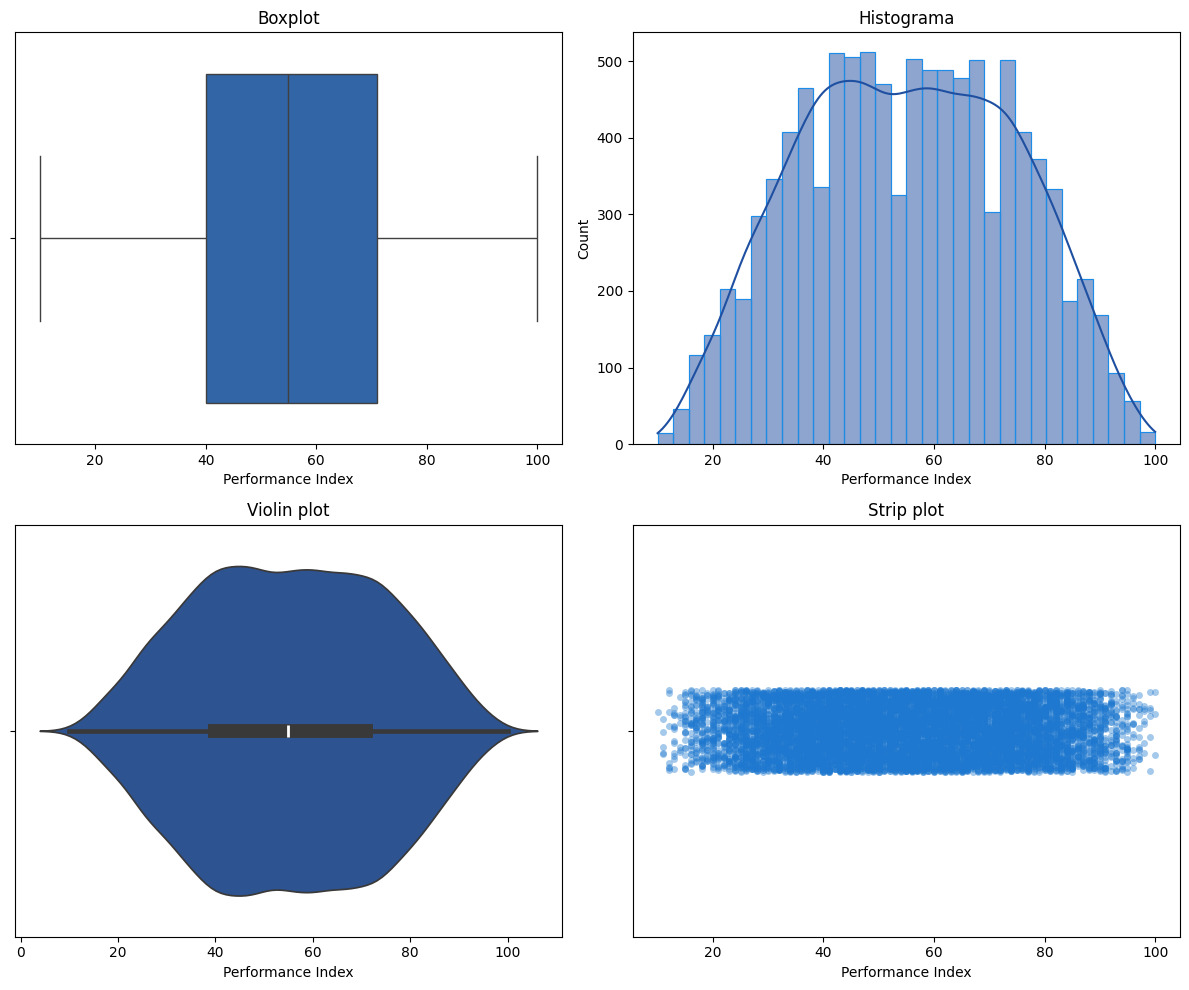

In [25]:
univariate_analysis(df_ma, 'Performance Index')

##### **ISI**

La variable ISI (Índice de Sostenibilidad Integral) presenta una distribución altamente sesgada a la derecha, con una gran concentración de valores bajos y una larga cola de valores elevados, como se observa en el histograma y el violin plot. El boxplot revela una cantidad considerable de valores atípicos hacia la derecha, lo cual indica que hay estudiantes con un índice de sostenibilidad mucho más alto que la mayoría. Esta dispersión también se refleja en el strip plot, donde se observa una densidad alta en valores bajos y puntos dispersos en los valores más altos. Esto sugiere que, aunque muchos de los estudiantes manejan una carga equilibrada en relación con su rendimiento y descanso, existe un grupo que podría estar sobrecargado o teniendo un rendimiento muy alto con poco descanso, lo cual podría afectar su sostenibilidad a largo plazo.

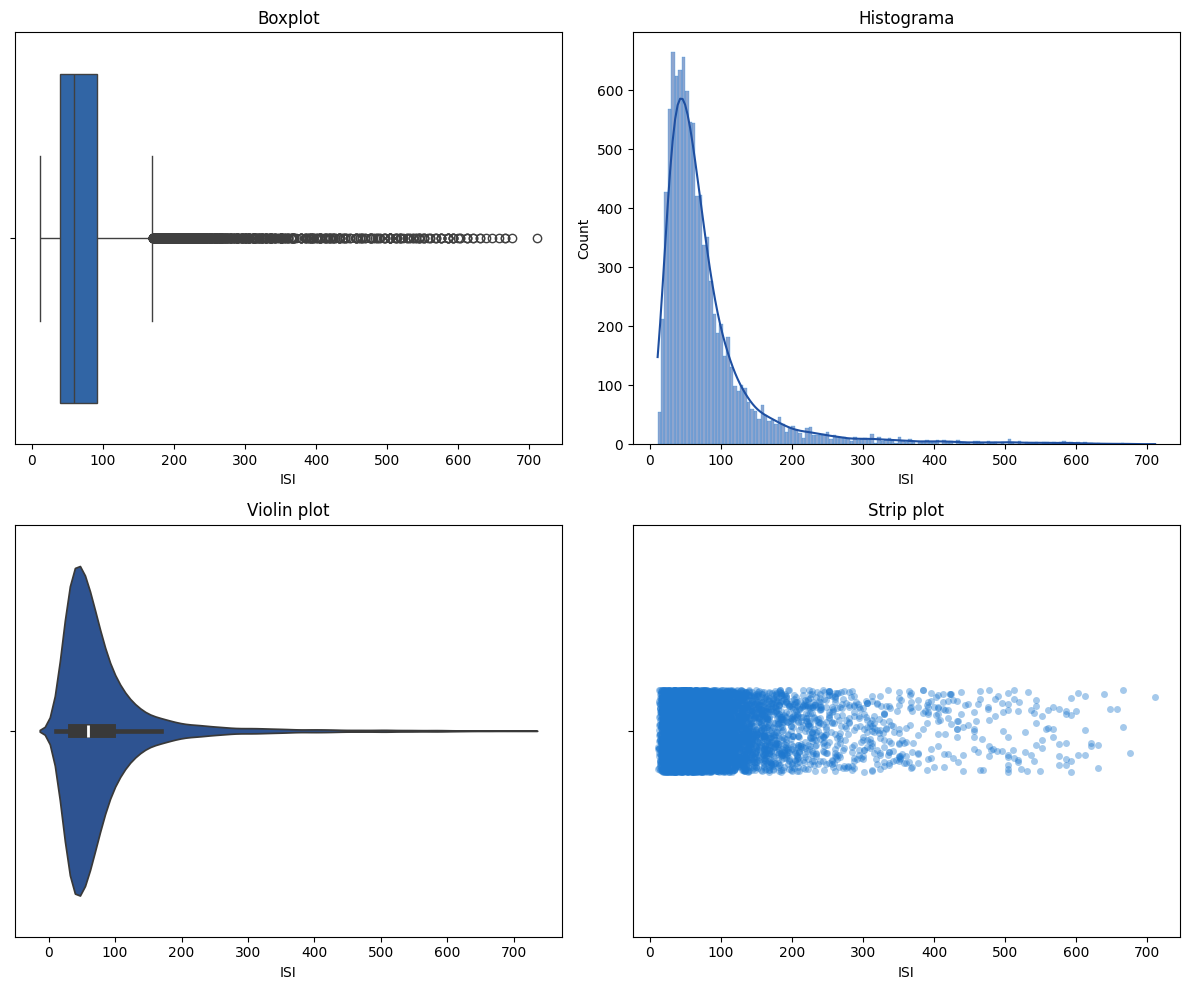

In [27]:
univariate_analysis(df_ma, 'ISI')

##### **IBI**

La variable IBI (Índice de Balance Integral) muestra una distribución fuertemente sesgada a la derecha, con la mayoría de los valores concentrados cerca de cero. El histograma indica que una gran parte de los estudiantes tiene un IBI muy bajo, lo que sugiere un desequilibrio entre estudio, sueño y actividades extracurriculares. El boxplot y el violin plot confirman que los valores están fuertemente agrupados en la parte baja del rango, con unos pocos valores atípicos que indican casos de mejor balance. En el strip plot, los puntos están mayormente concentrados a la izquierda, reforzando la idea de que la mayoría de los estudiantes no logran mantener un equilibrio integral adecuado en sus actividades, lo cual podría afectar su bienestar o desempeño académico a largo plazo.

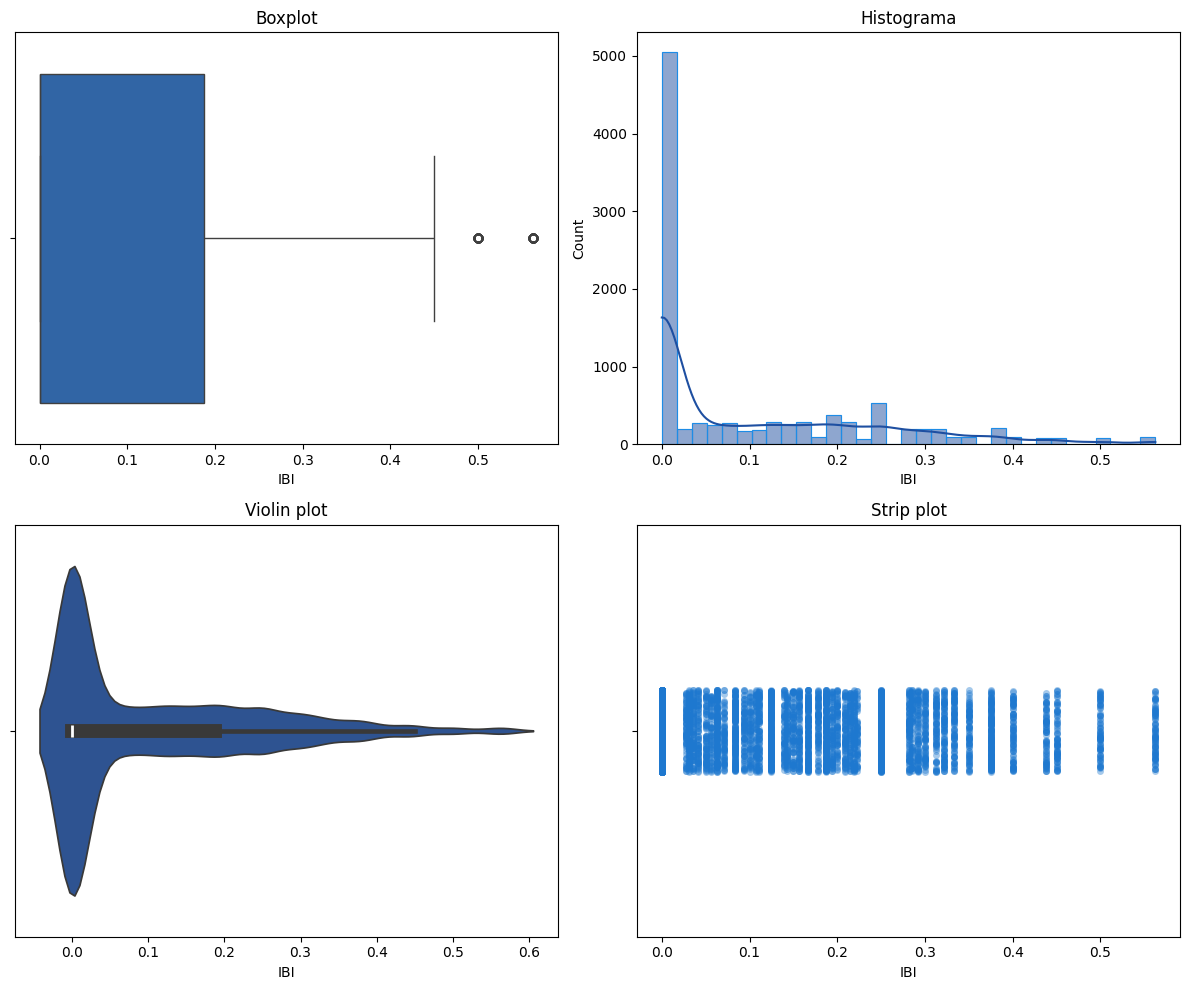

In [28]:
univariate_analysis(df_ma, 'IBI')

#### **IED**

La variable IED muestra una distribución sesgada a la derecha, con la mayoría de los estudiantes concentrados en valores bajos y medios del índice. Hay algunos valores atípicos altos que indican casos de alta eficiencia. En general, sugiere que muchos estudiantes podrían mejorar la forma en que traducen su dedicación en rendimiento académico.

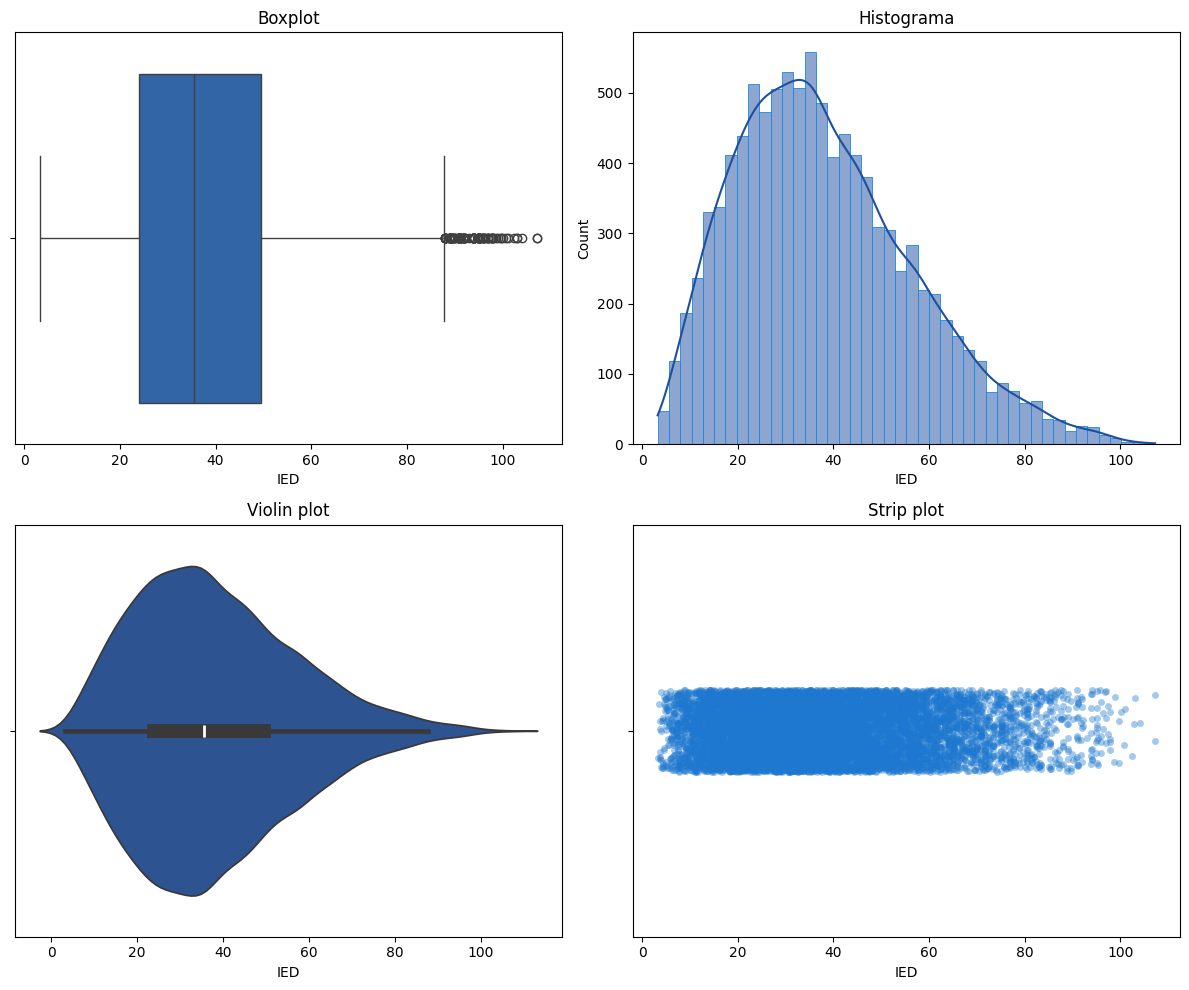

In [29]:
univariate_analysis(df_ma, 'IED')

 #### **Variables Enteras y Categorica**

Variable: Hours Studied


<ipython-input-23-fb8747a306a4>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[0], palette=DARK_BLUE_PALETTE[1:4])
<ipython-input-23-fb8747a306a4>:10: UserWarning: 
The palette list has fewer values (3) than needed (9) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=df, x=col, ax=axes[0], palette=DARK_BLUE_PALETTE[1:4])


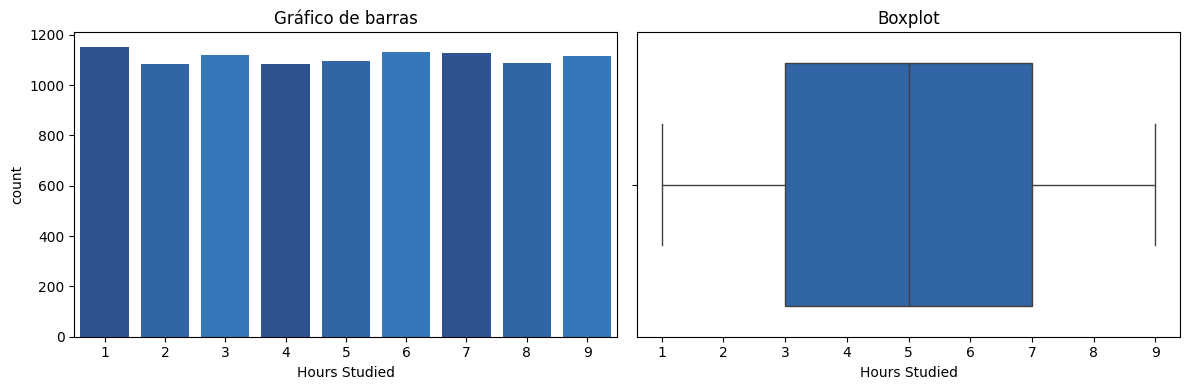

Variable: Sleep Hours


<ipython-input-23-fb8747a306a4>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[0], palette=DARK_BLUE_PALETTE[1:4])
<ipython-input-23-fb8747a306a4>:10: UserWarning: 
The palette list has fewer values (3) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=df, x=col, ax=axes[0], palette=DARK_BLUE_PALETTE[1:4])


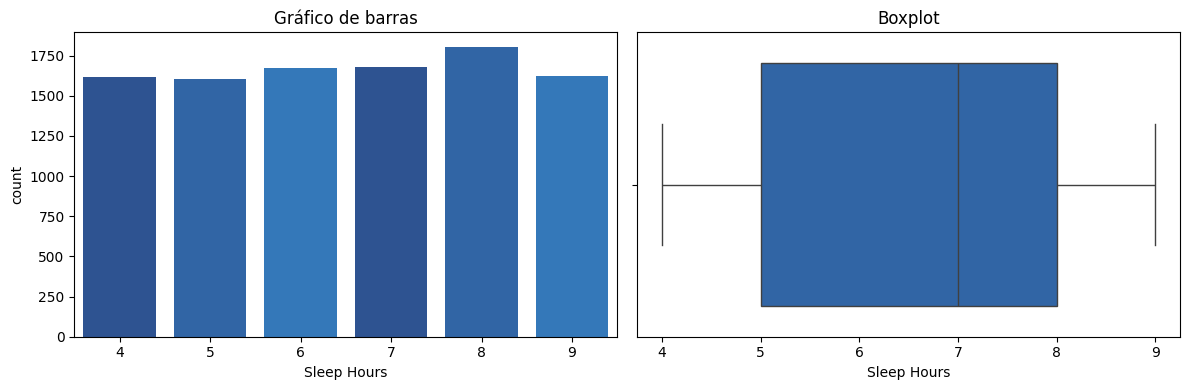

Variable: Sample Question Papers Practiced


<ipython-input-23-fb8747a306a4>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[0], palette=DARK_BLUE_PALETTE[1:4])
<ipython-input-23-fb8747a306a4>:10: UserWarning: 
The palette list has fewer values (3) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=df, x=col, ax=axes[0], palette=DARK_BLUE_PALETTE[1:4])


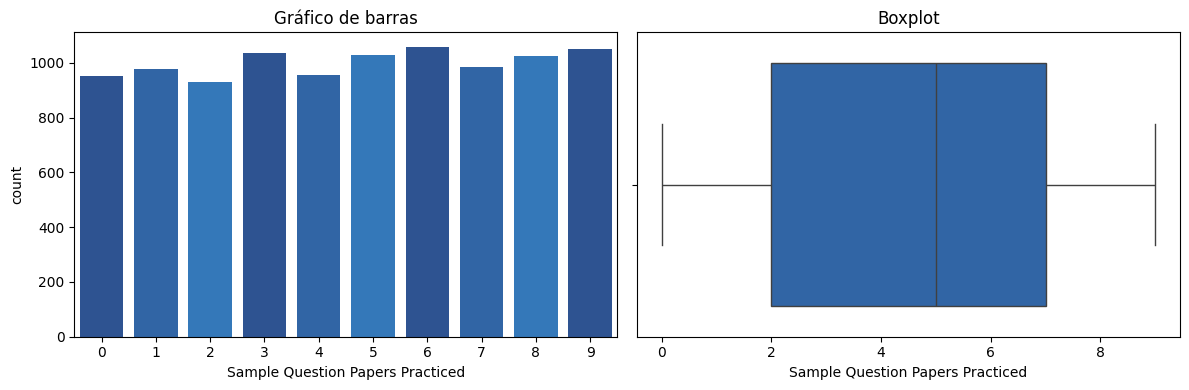

Variable: Extracurricular Hours


<ipython-input-23-fb8747a306a4>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[0], palette=DARK_BLUE_PALETTE[1:4])
<ipython-input-23-fb8747a306a4>:10: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.countplot(data=df, x=col, ax=axes[0], palette=DARK_BLUE_PALETTE[1:4])


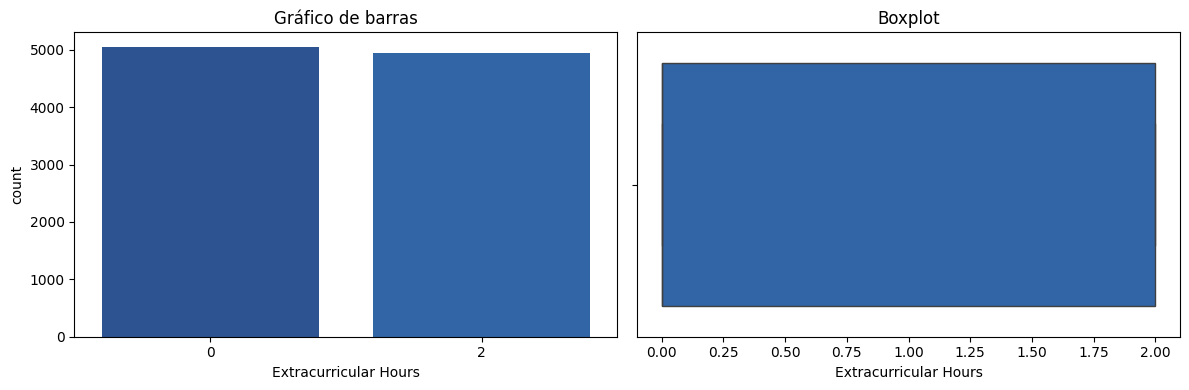

In [30]:
univariate_integer_analysis(df_ma)

Podemos notar que las clases no estan desbalanceadas, lo que nos soluciona un problema ya que para los modelos no tendremos que usar ningun tipo de balanceo, ya que cada clase tiene una cantidad representativa.

#### **Conclusion Univariado**

Nos pudimos dar cuenta que los datos en si se ven muy silenciosos ya que las clases y las notas aparentan una normalidad, sin embargo la creacion de los indicadores fueron muy valiosos ya que nos permitio llegar un poco mas alla del dato crudo y sacar provecho al maximo de estos datos.

#### **Bivariado**

##### **¿Existen diferencias estadísticas entre el puntaje final (Performance Index) y la asistencia a actividades extracurriculares?**

  Planteamiento de hipotesis (Haremos pruebas con un intervalo de confianza del 95%)

  Hipótesis nula **(H₀)**: No hay diferencia en el Performance Index entre quienes asisten y no asisten a actividades extracurriculares.

  Hipótesis alternativa **(H₁)** : Sí hay diferencia.

###### **Verificar supuesto de normalidad.**

In [ ]:
from scipy.stats import shapiro

grupo_yes = df_ma[df_ma['Extracurricular Activities'] == 'Yes']['Performance Index']
grupo_no = df_ma[df_ma['Extracurricular Activities'] == 'No']['Performance Index']

display(shapiro(grupo_yes))

display(shapiro(grupo_no))

ShapiroResult(statistic=np.float64(0.9832346389995872), pvalue=np.float64(8.844887408919619e-24))

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5052.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=np.float64(0.9848664875738351), pvalue=np.float64(7.459715935479959e-23))

- p-value grupo 'Yes': 8.84e-24

- p-value grupo 'No': 7.45e-23

Ambos p-valores son < 0.05, lo que indica que la variable Performance Index no sigue una distribución normal en ninguno de los grupos.

In [ ]:
from scipy.stats import mannwhitneyu

grupo_yes = df_ma[df_ma['Extracurricular Activities'] == 'Yes']['Performance Index']
grupo_no = df_ma[df_ma['Extracurricular Activities'] == 'No']['Performance Index']

stat, p = mannwhitneyu(grupo_yes, grupo_no, alternative='two-sided')
print(f'Estadístico U: {stat}, p-value: {p}')


Estadístico U: 12814910.5, p-value: 0.028424983372663623


Dado que el p-value < 0.05, se rechaza la hipótesis nula, por lo tanto:

Sí existen diferencias estadísticamente significativas en el Performance Index entre los estudiantes que asisten y los que no asisten a actividades extracurriculares.

##### **¿Existe relación entre las horas de estudio (Hours Studied) y la resolución de las actividades propuestas en el material de estudio (Sample Question Papers Practiced)?**

Aunque las variables sean numericas, tengamos en cuenta que ambas son variables enteras en un rango muy limitado, por lo cual una prueba de chi2 nos vendria mejor que una correlacion.

Hipótesis
**H₀ (Hipótesis nula)**:
No existe relación entre las horas de estudio y la cantidad de ejercicios resueltos.

**H₁ (Hipótesis alternativa)**:
Sí existe una relación entre las horas de estudio y la cantidad de ejercicios resueltos.

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

tabla = pd.crosstab(df_ma['Hours Studied'], df_ma['Sample Question Papers Practiced'])
chi2, p, dof, expected = chi2_contingency(tabla)
print(f'Estadístico chi2: {chi2}, p-value: {p}')



Estadístico chi2: 69.06089015277684, p-value: 0.5763471030511849


Verificamos chi2 entre las variables.
Como p ≥ 0.05, no hay relación estadísticamente significativa entre ambas variables.

### **Estudio relaciones entre variables y grupos**

In [ ]:
variables = ['Hours Studied', 'Sleep Hours', 'Sample Question Papers Practiced',
             'Extracurricular Hours', 'Performance Index', 'ISI', 'IBI', 'IED']
df_cluster = df_ma[variables].dropna()
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df_cluster['Cluster'] = kmeans.fit_predict(X_scaled)

df_ma['Cluster'] = df_cluster['Cluster']

df_ma.groupby('Cluster')[variables].describe().round(2)


Hours Studied                                      Sleep Hours        \
                count  mean   std  min  25%  50%  75%  max       count  mean   
Cluster                                                                        
0              3978.0  7.08  1.66  2.0  6.0  7.0  9.0  9.0      3978.0  6.62   
1              1601.0  2.29  1.33  1.0  1.0  2.0  3.0  6.0      1601.0  7.47   
2              4421.0  4.10  2.17  1.0  2.0  4.0  6.0  9.0      4421.0  6.10   

         ...   IBI           IED                                            \
         ...   75%   max   count   mean    std    min    25%    50%    75%   
Cluster  ...                                                                 
0        ...  0.29  0.56  3978.0  54.54  14.64  22.21  43.75  52.25  63.75   
1        ...  0.00  0.09  1601.0  35.82  12.55   8.25  26.67  35.62  44.62   
2        ...  0.12  0.50  4421.0  23.91   8.95   3.25  17.25  24.00  30.88   

                 
            max  
Cluster          
0        107.25  
1         76.12  
2         45.75  

[3 rows x 64 columns]

**Cluster 0: Estudiantes altamente dedicados**

**Horas de estudio:** Altas (media ≈ 7.08)

**Horas de sueño:** Moderadas

**IED:** Alto (≈ 54.5) → alta eficiencia

**IBI:** Más alto del grupo (≈ 0.29)

 Perfil: Estudiantes que estudian mucho, duermen lo justo y logran un buen equilibrio y eficiencia.

**Cluster 1: Estudiantes relajados**
**Horas de estudio:** Muy bajas (≈ 2.29)

**Horas de sueño:** Más altas del grupo (≈ 7.47)

**IED:** Medio-bajo (≈ 35.8)

**IBI:** Cercano a cero

 Perfil: Duermen más, estudian poco y hacen pocos ejercicios. Bajo rendimiento relativo.

**Cluster 2:** Esfuerzo intermedio, baja eficiencia
**Horas de estudio:** Moderadas (≈ 4.10)

**Sueño:** El más bajo (≈ 6.10)

**IED:** Más bajo del grupo (≈ 23.9)

 Perfil: Estudian y se esfuerzan, pero no logran traducirlo en eficiencia o balance.

## **Modelos y métricas**

### **Modelo Lineal**

In [33]:
X = df_ma[['Hours Studied', 'Sleep Hours', 'Sample Question Papers Practiced',
           'Extracurricular Hours', 'ISI', 'IBI', 'IED']]
y = df_ma['Performance Index']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = LinearRegression()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

In [34]:
coef = pd.Series(modelo.coef_, index=X.columns).sort_values(key=abs, ascending=False)
display(coef)

,0
IBI,-7.374848
Sleep Hours,-3.457249
Sample Question Papers Practiced,-3.018932
Hours Studied,-2.136349
Extracurricular Hours,1.456545
IED,1.314269
ISI,0.027698


#### **Validación y desempeño**

In [35]:
print('R²:', r2_score(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('MAE:', mean_absolute_error(y_test, y_pred))

R²: 0.9369380077983451
RMSE: 4.834235792267624
MAE: 3.4773721488755536


####**Métrica de negocio recomendada**

Cuando se trata de predecir puntajes, lo más útil es saber **cuánto se equivoca el modelo en promedio por cada observación**. En ese sentido, el **MAE** es la métrica ideal, ya que muestra directamente el error medio de lo que predice el modelo y el valor real. Es fácil de interpretar y refleja de forma clara cuánto se está desviando el modelo al estimar el desempeño de cada estudiante.

#### **¿Es la regresión adecuada?**

La regresión lineal puede ser una buena forma pero para comenzar ya que no posee mucha complejidad en su cálculo, pero si hay relaciones no lineales, efectos combinados o interacción entre variables, modelos más complejos como árboles o ensambles pueden tener mejor rendimiento, pero eso se va viendo conforme uno vaya entendiendo los datos.

### **Comparacion otros modelos**

In [38]:
# Árbol de decisión
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Comparación de R2
print('Lineal R²:', mean_absolute_error(y_test, y_pred))
print('Árbol R²:', mean_absolute_error(y_test, dt_pred))
print('RF R²:', mean_absolute_error(y_test, rf_pred))


Lineal R²: 3.4773721488755536
Árbol R²: 2.585
RF R²: 1.488705


Notemos que modelos mas robustos como lo son **Decision Tree** y **RandomForestRegresor** lograr captar de una forma mas cercana el comportamiento de los datos, que un modelo lineal, sin embargo son modelos mas dificiles de calcular computacionalmente, por lo que una regresion lineal no lo hace mal esta vez.

## **Conclusión**

A partir del análisis realizado, se evidenció que el desempeño académico (`Performance Index`) de los estudiantes está influenciado principalmente por el balance entre estudio, descanso y actividades extracurriculares. El Índice de Balance Integral (`IBI`) resultó ser la variable más explicativa en el modelo de regresión lineal, con un impacto negativo notable cuando el equilibrio es deficiente.

El modelo de regresión alcanzó un **$R^2$ de 0.93**, lo que indica un alto poder explicativo, y un MAE razonable que lo hace útil para estimar el rendimiento individual. Al definir una métrica de negocio, el MAE fue elegido por su fácil interpretación: indica cuánto se equivoca el modelo en promedio por estudiante.

Sin embargo, se identificó que modelos como Árboles de Decisión o Random Forest podrían capturar relaciones no lineales que la regresión lineal no detecta. Por tanto, aunque la regresión es un buen punto de partida, no necesariamente es el método más adecuado si se busca mayor precisión en la predicción del rendimiento.

En resumen, el equilibrio en la vida académica importa tanto como las horas de estudio, y los modelos predictivos pueden ayudar a identificar estudiantes en riesgo de bajo rendimiento o con potencial de mejora.